<a href="https://colab.research.google.com/github/manasvik2006/CodSoft/blob/main/spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Download all required NLTK data
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\b\d{10,}\b', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print('✅ Preprocessing complete!')
for i in [3, 4, 5]:
    print(f'  BEFORE: {df["message"].iloc[i][:80]}')
    print(f'  AFTER : {df["clean_message"].iloc[i][:80]}\n')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Preprocessing complete!
  BEFORE: U dun say so early hor... U c already then say...
  AFTER : dun say early hor already say

  BEFORE: Nah I don't think he goes to usf, he lives around here though
  AFTER : nah dont think go usf life around though

  BEFORE: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some
  AFTER : freemsg hey darling week word back like fun still xxx std chgs send rcv



In [ ]:
# ---------------------------------------------------------------
# Upload spam.csv in Colab using the file upload widget,
# OR mount Google Drive and update the path accordingly.
# ---------------------------------------------------------------
from google.colab import files
uploaded = files.upload()   # Select spam.csv from your machine

# Load dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]                    # Keep only label and message columns
df.columns = ['label', 'message']        # Rename for clarity

print(f'Dataset shape: {df.shape}')
print(f'\nLabel distribution:\n{df["label"].value_counts()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(10)

Saving spam.csv to spam.csv
Dataset shape: (5572, 2)

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


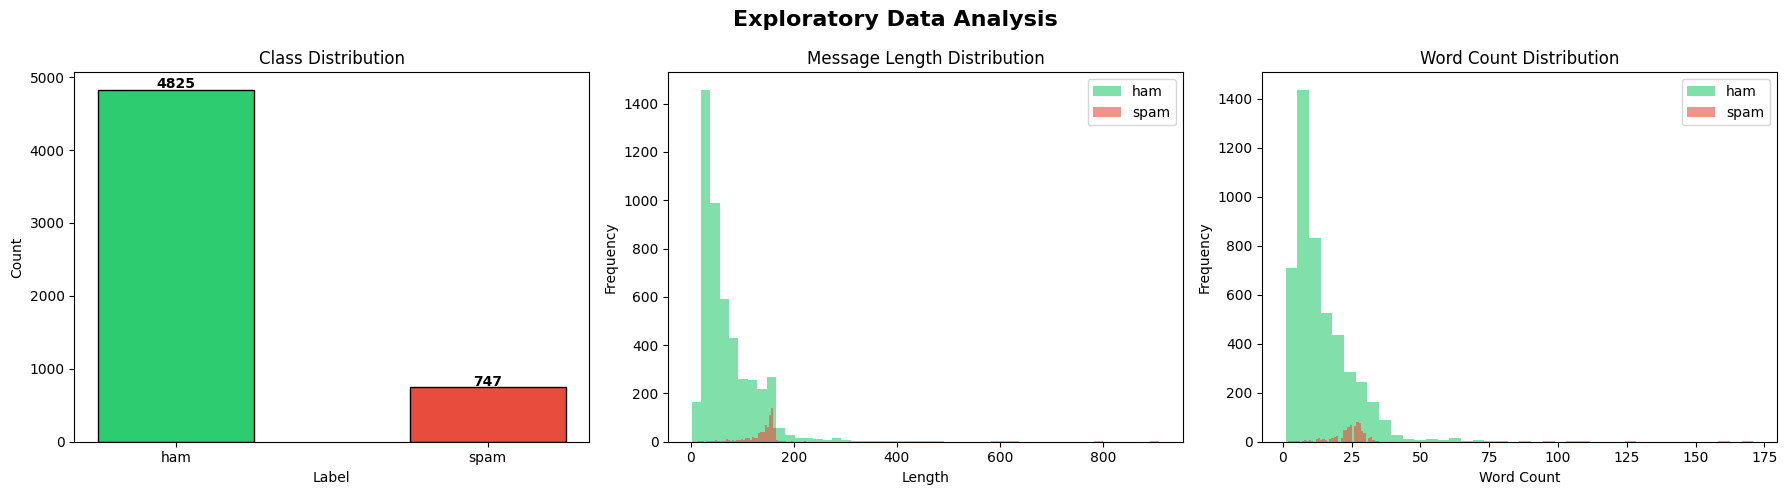


Avg message length  →  Ham: 71.0  |  Spam: 138.9
Avg word count      →  Ham: 14.2  |  Spam: 23.9


In [ ]:
# --- EDA Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Class Distribution
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# 2. Message Length Distribution
df['msg_length'] = df['message'].apply(len)
for label, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
    axes[1].hist(df[df['label'] == label]['msg_length'],
                 bins=50, alpha=0.6, label=label, color=color)
axes[1].set_title('Message Length Distribution')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 3. Word Count Distribution
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
for label, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
    axes[2].hist(df[df['label'] == label]['word_count'],
                 bins=40, alpha=0.6, label=label, color=color)
axes[2].set_title('Word Count Distribution')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg message length  →  Ham: {df[df['label']=='ham']['msg_length'].mean():.1f}  |  Spam: {df[df['label']=='spam']['msg_length'].mean():.1f}")
print(f"Avg word count      →  Ham: {df[df['label']=='ham']['word_count'].mean():.1f}  |  Spam: {df[df['label']=='spam']['word_count'].mean():.1f}")

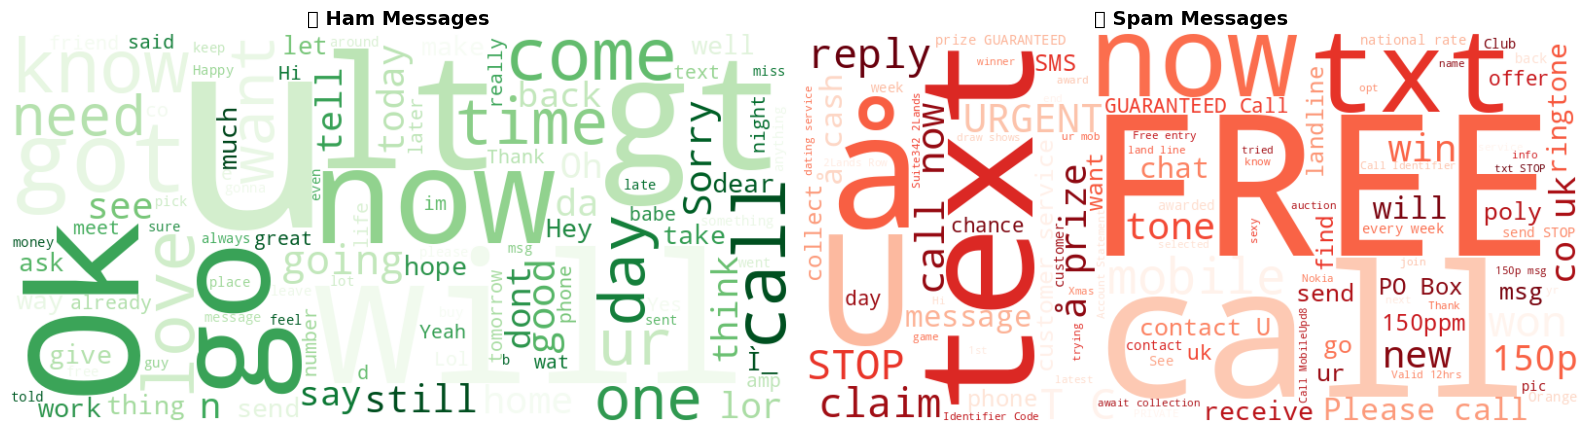

In [ ]:
# --- Word Clouds ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, cmap, title in [
    (axes[0], 'ham',  'Greens',  '🟢 Ham Messages'),
    (axes[1], 'spam', 'Reds',    '🔴 Spam Messages')
]:
    text = ' '.join(df[df['label'] == label]['message'])
    wc = WordCloud(width=800, height=400, colormap=cmap,
                   background_color='white', max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """Full NLP preprocessing pipeline."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\b\d{10,}\b', '', text)
    # Remove punctuation & digits
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords & short tokens, then lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess)

# Encode labels: ham=0, spam=1
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print('✅ Preprocessing complete!')
print('\nSample before / after:')
for i in [3, 4, 5]:
    print(f'  BEFORE: {df["message"].iloc[i][:80]}')
    print(f'  AFTER : {df["clean_message"].iloc[i][:80]}\n')

✅ Preprocessing complete!

Sample before / after:
  BEFORE: U dun say so early hor... U c already then say...
  AFTER : dun say early hor already say

  BEFORE: Nah I don't think he goes to usf, he lives around here though
  AFTER : nah dont think go usf life around though

  BEFORE: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some
  AFTER : freemsg hey darling week word back like fun still xxx std chgs send rcv



In [ ]:
X = df['clean_message']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'\nTrain spam ratio: {y_train.mean():.3f}')
print(f'Test  spam ratio: {y_test.mean():.3f}')

Training samples : 4457
Testing  samples : 1115

Train spam ratio: 0.134
Test  spam ratio: 0.134


In [ ]:
# TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF feature matrix shape: {X_train_tfidf.shape}')

# Top TF-IDF terms for spam vs ham
feature_names = np.array(tfidf.get_feature_names_out())
spam_idx  = np.where(y_train == 1)[0]
ham_idx   = np.where(y_train == 0)[0]

spam_tfidf_mean = np.asarray(X_train_tfidf[spam_idx].mean(axis=0)).flatten()
ham_tfidf_mean  = np.asarray(X_train_tfidf[ham_idx].mean(axis=0)).flatten()

top_spam = feature_names[np.argsort(spam_tfidf_mean)[-15:][::-1]]
top_ham  = feature_names[np.argsort(ham_tfidf_mean)[-15:][::-1]]

print(f'\n🔴 Top SPAM terms : {list(top_spam)}')
print(f'🟢 Top HAM  terms : {list(top_ham)}')

TF-IDF feature matrix shape: (4457, 6647)

🔴 Top SPAM terms : ['call', 'free', 'txt', 'claim', 'text', 'mobile', 'stop', 'reply', 'service', 'prize', 'new', 'urgent', 'cash', 'win', 'tone']
🟢 Top HAM  terms : ['get', 'ill', 'come', 'got', 'ltgt', 'dont', 'know', 'call', 'like', 'time', 'good', 'home', 'going', 'want', 'lor']


In [ ]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Train, predict, and return evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Probability for ROC-AUC (use decision_function if predict_proba absent)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)

    metrics = {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_te, y_pred) * 100, 2),
        'Precision': round(precision_score(y_te, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_te, y_pred) * 100, 2),
        'F1-Score' : round(f1_score(y_te, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_prob) * 100, 2),
    }
    return metrics, y_pred, y_prob, model

# --- Define models ---
models = {
    'Naive Bayes'         : MultinomialNB(alpha=0.1),
    'Logistic Regression' : LogisticRegression(C=5, max_iter=1000, random_state=42),
    'Linear SVM'          : LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results      = []
trained_models = {}
all_probs    = {}

print('Training models on TF-IDF features...\n')
for name, model in models.items():
    metrics, y_pred, y_prob, trained = evaluate_model(
        model, X_train_tfidf, X_test_tfidf, y_train, y_test, name
    )
    results.append(metrics)
    trained_models[name] = trained
    all_probs[name]       = y_prob
    print(f'  ✅ {name:22s} — Acc: {metrics["Accuracy"]}%  F1: {metrics["F1-Score"]}%  AUC: {metrics["ROC-AUC"]}%')

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print('\n📊 Full Results Table:')
display(results_df.reset_index(drop=True))

Training models on TF-IDF features...

  ✅ Naive Bayes            — Acc: 97.4%  F1: 89.68%  AUC: 98.39%
  ✅ Logistic Regression    — Acc: 98.12%  F1: 92.53%  AUC: 98.45%
  ✅ Linear SVM             — Acc: 98.48%  F1: 94.08%  AUC: 98.18%
  ✅ Random Forest          — Acc: 97.49%  F1: 89.71%  AUC: 98.67%

📊 Full Results Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Linear SVM,98.48,97.83,90.60,94.08,98.18
1,Logistic Regression,98.12,98.48,87.25,92.53,98.45
2,Random Forest,97.49,99.19,81.88,89.71,98.67
3,Naive Bayes,97.40,95.45,84.56,89.68,98.39


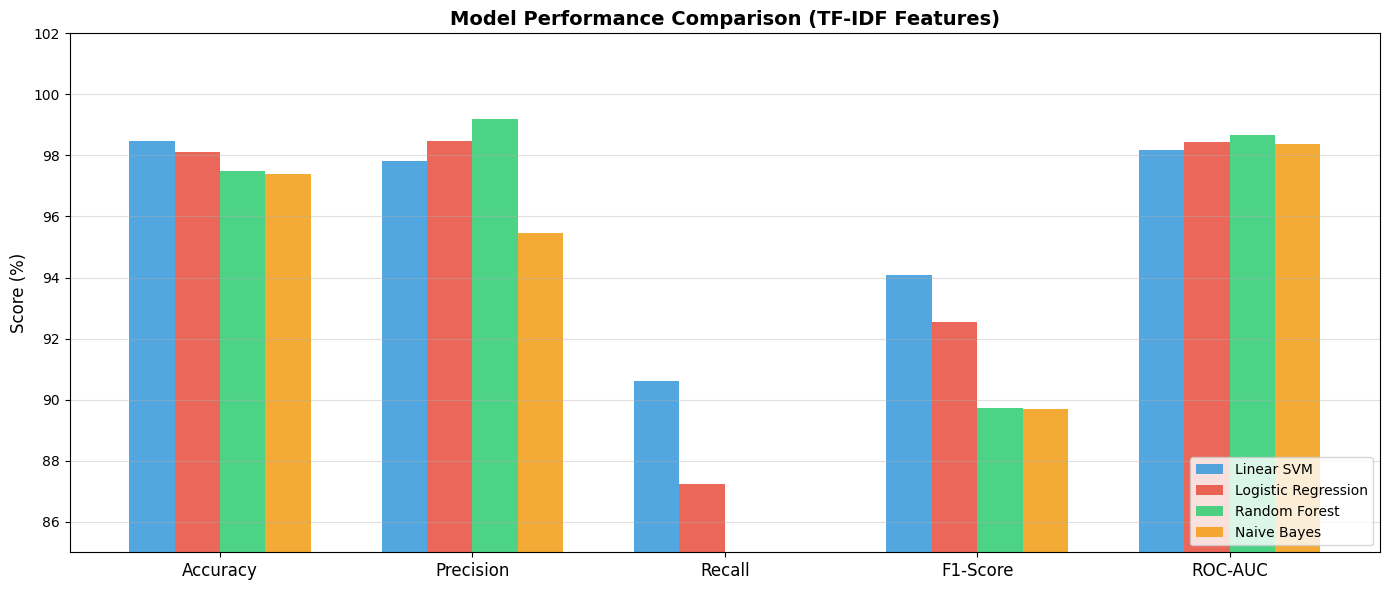

In [ ]:
# --- Metrics Bar Chart ---
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_cols))
width = 0.18
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_cols]
    bars = ax.bar(x + i * width, vals, width, label=row['Model'], color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_cols, fontsize=12)
ax.set_ylim(85, 102)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison (TF-IDF Features)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

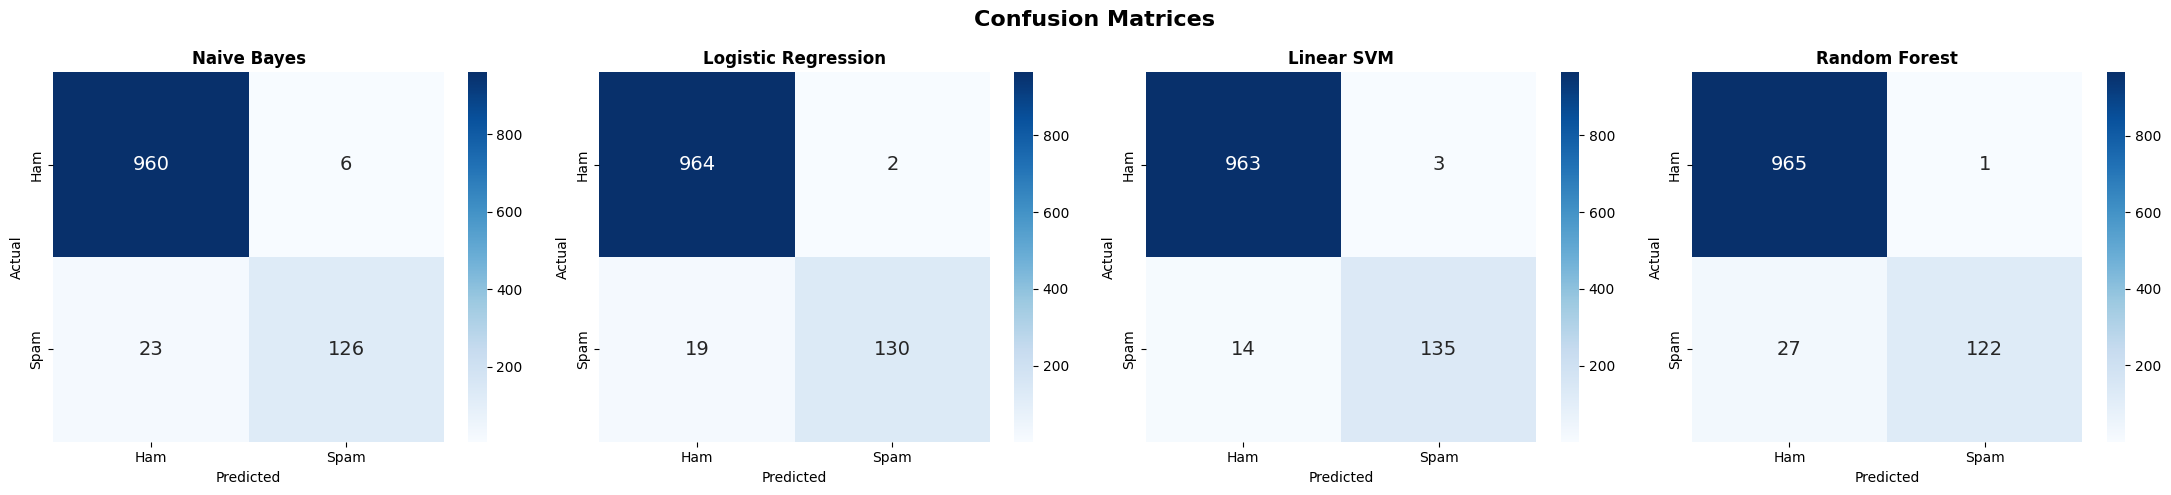

In [ ]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'],
                annot_kws={'size': 14})
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

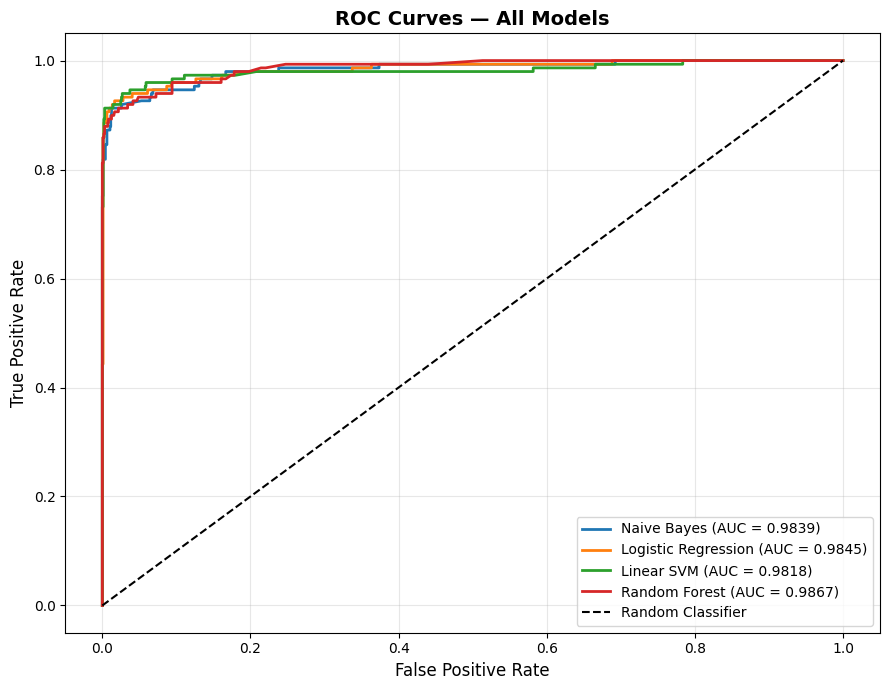

In [ ]:
# --- ROC Curves ---
plt.figure(figsize=(9, 7))
for name, y_prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tokenize for Word2Vec
X_train_tokens = [text.split() for text in X_train]
X_test_tokens  = [text.split() for text in X_test]

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=15,
    seed=42
)

def message_to_vector(tokens, model, dim=100):
    """Average Word2Vec vectors for all known words in the message."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_train_w2v = np.array([message_to_vector(t, w2v_model) for t in X_train_tokens])
X_test_w2v  = np.array([message_to_vector(t, w2v_model) for t in X_test_tokens])

print(f'Word2Vec feature matrix shape: {X_train_w2v.shape}')

# Train Logistic Regression on W2V embeddings
lr_w2v = LogisticRegression(C=5, max_iter=1000, random_state=42)
lr_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = lr_w2v.predict(X_test_w2v)
y_prob_w2v = lr_w2v.predict_proba(X_test_w2v)[:, 1]

print('\n📋 Word2Vec + Logistic Regression Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_w2v)*100:.2f}%')
print(f'  Precision : {precision_score(y_test, y_pred_w2v)*100:.2f}%')
print(f'  Recall    : {recall_score(y_test, y_pred_w2v)*100:.2f}%')
print(f'  F1-Score  : {f1_score(y_test, y_pred_w2v)*100:.2f}%')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_w2v)*100:.2f}%')

# Similar words from embeddings
print('\n🔗 Words similar to "free" in trained embeddings:')
print([w for w, _ in w2v_model.wv.most_similar('free', topn=8)])

Word2Vec feature matrix shape: (4457, 100)

📋 Word2Vec + Logistic Regression Results:
  Accuracy  : 94.98%
  Precision : 85.50%
  Recall    : 75.17%
  F1-Score  : 80.00%
  ROC-AUC   : 95.93%

🔗 Words similar to "free" in trained embeddings:
['camcorder', 'mobile', 'nokia', 'tone', 'txt', 'stop', 'stoptxt', 'arrive']


🏆 Best Model: Linear SVM

10-Fold Cross-Validation F1 Scores:
   [94.37 93.79 91.97 95.83 92.2  90.65 91.3  91.3  92.52 93.06]

  Mean F1 : 92.70%
  Std  F1 : 1.51%


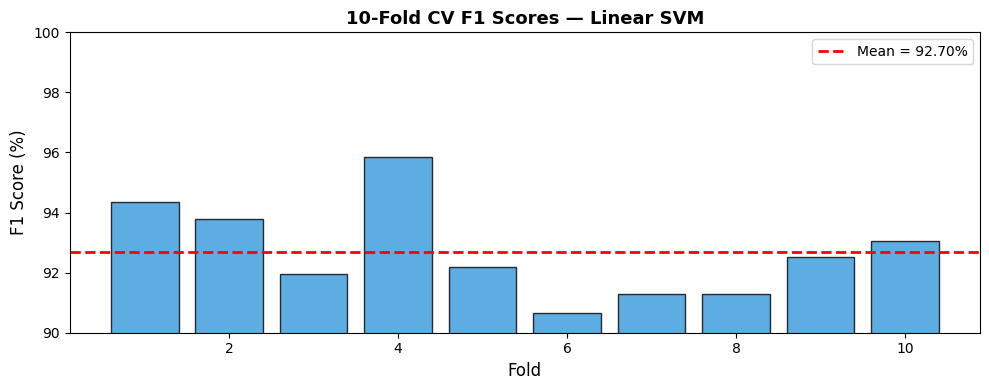

In [ ]:
# Best model from results
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]

# Re-vectorize on full dataset for CV
X_all_tfidf = tfidf.transform(df['clean_message'])
y_all        = df['label_enc'].values

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_all_tfidf, y_all,
                             cv=cv, scoring='f1', n_jobs=-1)

print(f'🏆 Best Model: {best_model_name}')
print(f'\n10-Fold Cross-Validation F1 Scores:')
print('  ', np.round(cv_scores * 100, 2))
print(f'\n  Mean F1 : {cv_scores.mean()*100:.2f}%')
print(f'  Std  F1 : {cv_scores.std()*100:.2f}%')

# Plot CV scores
plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), cv_scores * 100, color='#3498db', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--', lw=2,
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('F1 Score (%)', fontsize=12)
plt.title(f'10-Fold CV F1 Scores — {best_model_name}', fontsize=13, fontweight='bold')
plt.legend()
plt.ylim(90, 100)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Use best TF-IDF model for the interactive predictor
best_clf = trained_models[best_model_name]

def predict_spam(message):
    """Predict whether a message is spam or ham."""
    cleaned = preprocess(message)
    vec     = tfidf.transform([cleaned])
    pred    = best_clf.predict(vec)[0]
    label   = '🔴 SPAM' if pred == 1 else '🟢 HAM'

    if hasattr(best_clf, 'predict_proba'):
        prob = best_clf.predict_proba(vec)[0][pred]
    else:
        # SVM decision function — convert to pseudo-probability via sigmoid
        score = best_clf.decision_function(vec)[0]
        prob  = 1 / (1 + np.exp(-score))

    print(f'  Message   : {message[:80]}')
    print(f'  Prediction: {label}  |  Confidence: {prob*100:.1f}%\n')

# --- Test messages ---
test_messages = [
    "WINNER!! As a valued network customer you have been selected to receive a £900 prize reward!",
    "Hey, are we still meeting for lunch tomorrow?",
    "FREE entry to win a £1000 cash prize! Text WIN to 80085 now!",
    "Can you please send me the project report by end of day?",
    "Congratulations! You've been selected for a special discount. Call now: 1800-FREE",
    "I'll be home by 8. Don't forget to pick up groceries.",
]

print(f'🤖 Spam Detector — Model: {best_model_name}\n' + '='*60)
for msg in test_messages:
    predict_spam(msg)

🤖 Spam Detector — Model: Linear SVM
  Message   : WINNER!! As a valued network customer you have been selected to receive a £900 p
  Prediction: 🔴 SPAM  |  Confidence: 64.7%

  Message   : Hey, are we still meeting for lunch tomorrow?
  Prediction: 🟢 HAM  |  Confidence: 17.5%

  Message   : FREE entry to win a £1000 cash prize! Text WIN to 80085 now!
  Prediction: 🔴 SPAM  |  Confidence: 78.4%

  Message   : Can you please send me the project report by end of day?
  Prediction: 🟢 HAM  |  Confidence: 29.7%

  Message   : Congratulations! You've been selected for a special discount. Call now: 1800-FRE
  Prediction: 🟢 HAM  |  Confidence: 47.2%

  Message   : I'll be home by 8. Don't forget to pick up groceries.
  Prediction: 🟢 HAM  |  Confidence: 25.1%



In [ ]:
# --- Interactive prediction (enter your own message) ---
user_msg = input('\n📩 Enter an SMS message to classify: ')
predict_spam(user_msg)

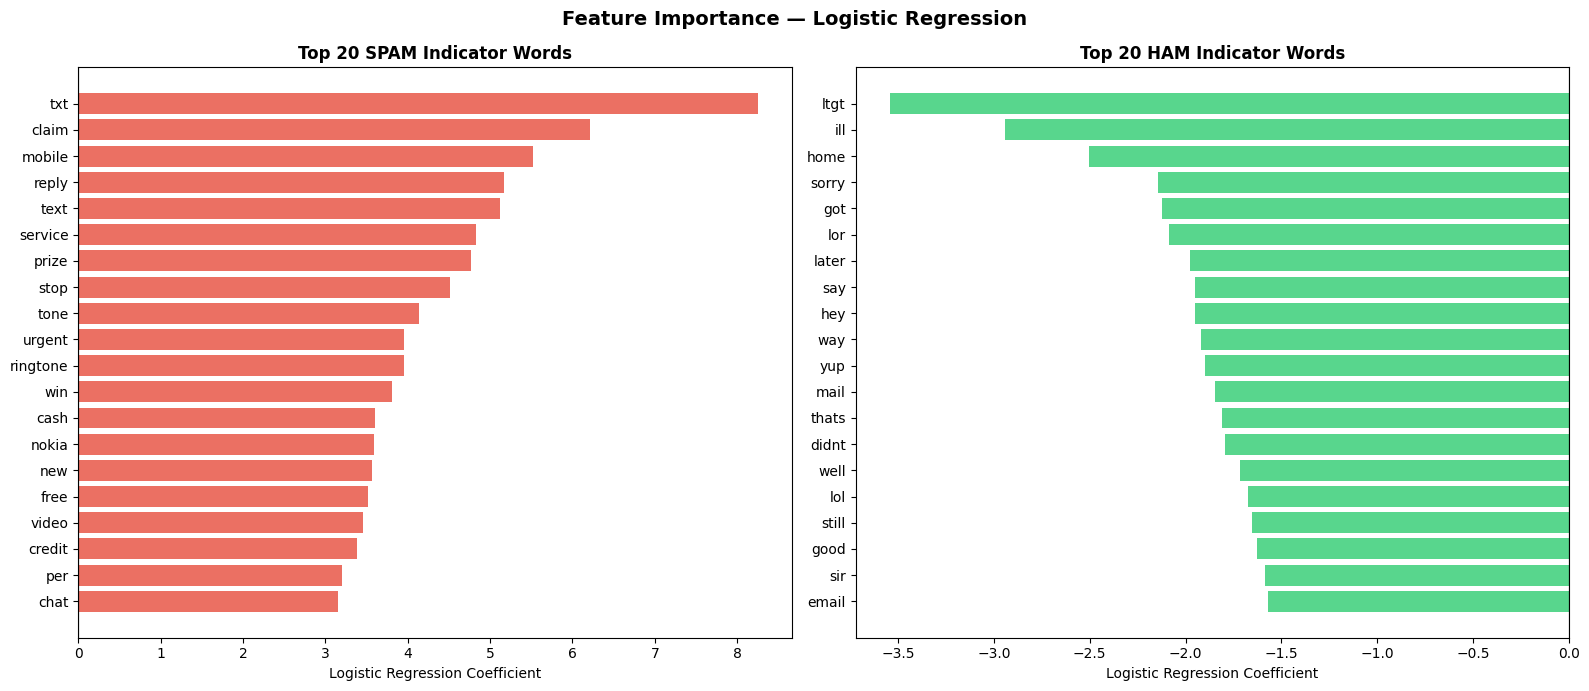

In [ ]:
# Retrain LR for interpretability analysis
lr_model = LogisticRegression(C=5, max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

feature_names_arr = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_n = 20
top_spam_idx = np.argsort(coefs)[-top_n:][::-1]
top_ham_idx  = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Spam features
axes[0].barh(feature_names_arr[top_spam_idx][::-1],
             coefs[top_spam_idx][::-1], color='#e74c3c', alpha=0.8)
axes[0].set_title(f'Top {top_n} SPAM Indicator Words', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].axvline(0, color='black', lw=0.8)

# Ham features
axes[1].barh(feature_names_arr[top_ham_idx][::-1],
             coefs[top_ham_idx][::-1], color='#2ecc71', alpha=0.8)
axes[1].set_title(f'Top {top_n} HAM Indicator Words', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].axvline(0, color='black', lw=0.8)

plt.suptitle('Feature Importance — Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pickle

# Save vectorizer + model together as a pipeline-like dict
model_bundle = {
    'vectorizer': tfidf,
    'model'     : best_clf,
    'model_name': best_model_name
}

with open('spam_detector.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'✅ Model saved as spam_detector.pkl')

# Download from Colab
from google.colab import files
files.download('spam_detector.pkl')

# --- Load & verify ---
with open('spam_detector.pkl', 'rb') as f:
    loaded = pickle.load(f)

test_vec = loaded['vectorizer'].transform([preprocess("You won a free prize! Call now!")])
print(f'\n🔁 Load verification — Prediction: {"SPAM" if loaded["model"].predict(test_vec)[0] == 1 else "HAM"}')

✅ Model saved as spam_detector.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🔁 Load verification — Prediction: SPAM
